<a href="https://colab.research.google.com/github/Rasya-ai-web/Machine-Learning-Lab/blob/main/ML_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Image Generation Using GAN

In [18]:

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
import matplotlib.pyplot as plt
import numpy as np

In [19]:

# Load MNIST dataset
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

In [20]:

# Normalize images
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

# Generator
generator = Sequential([
    Dense(128, activation="relu", input_shape=(100,)),
    Dense(256, activation="relu"),
    Dense(28 * 28, activation="tanh"),
    Reshape((28, 28, 1))
])

# Discriminator
discriminator = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
# Compile discriminator
discriminator.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Create GAN
discriminator.trainable = False

gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [22]:
  # Training parameters
epochs = 20
batch_size = 128

for epoch in range(epochs):
   # Select real images
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_images = X_train[idx]

    # Generate fake images
    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_images = generator.predict(noise, verbose=0)

    # Train discriminator
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    discriminator.trainable = True

    d_loss_real = discriminator.train_on_batch(
        real_images.reshape(-1, 28, 28, 1),
        real_labels
    )

    d_loss_fake = discriminator.train_on_batch(
        fake_images,
        fake_labels
    )


    # Train generator
    discriminator.trainable = False

    noise = np.random.normal(0, 1, (batch_size, 100))

    g_loss = gan.train_on_batch(
        noise,
        real_labels
    )

    print(
        "Epoch:", epoch + 1,
        "D Loss:", (d_loss_real[0] + d_loss_fake[0]) / 2,
        "G Loss:", g_loss
    )

Epoch: 1 D Loss: 0.4522145 G Loss: 0.69224507
Epoch: 2 D Loss: 0.52240956 G Loss: 0.6170291
Epoch: 3 D Loss: 0.57317555 G Loss: 0.56126887
Epoch: 4 D Loss: 0.61818 G Loss: 0.52441734
Epoch: 5 D Loss: 0.6523849 G Loss: 0.5107063
Epoch: 6 D Loss: 0.66365415 G Loss: 0.5352356
Epoch: 7 D Loss: 0.6447772 G Loss: 0.6141477
Epoch: 8 D Loss: 0.6019075 G Loss: 0.7663455
Epoch: 9 D Loss: 0.5499635 G Loss: 0.9833177
Epoch: 10 D Loss: 0.5043564 G Loss: 1.21783
Epoch: 11 D Loss: 0.46353638 G Loss: 1.420609
Epoch: 12 D Loss: 0.42745996 G Loss: 1.5714673
Epoch: 13 D Loss: 0.39769155 G Loss: 1.6799935
Epoch: 14 D Loss: 0.373927 G Loss: 1.7568156
Epoch: 15 D Loss: 0.35446924 G Loss: 1.848429
Epoch: 16 D Loss: 0.33686137 G Loss: 1.9602892
Epoch: 17 D Loss: 0.3215544 G Loss: 2.0631306
Epoch: 18 D Loss: 0.3069359 G Loss: 2.160165
Epoch: 19 D Loss: 0.29274952 G Loss: 2.2579322
Epoch: 20 D Loss: 0.27953705 G Loss: 2.3640916


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


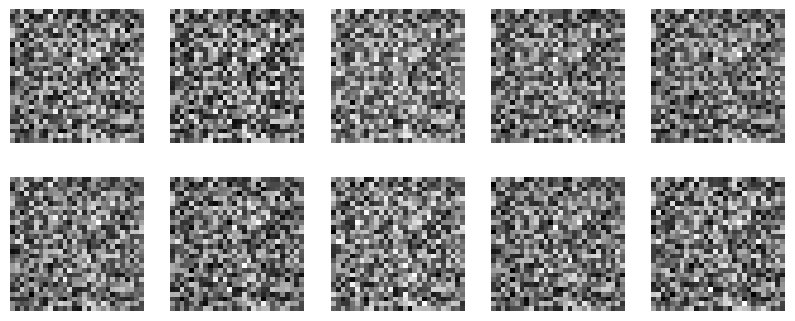

In [23]:

# Generate images
noise = np.random.normal(0, 1, (10, 100))
generated_images = generator.predict(noise)

# Display images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

Epoch: 1 D Loss: 0.1084 G Loss: 4.9041
Epoch: 2 D Loss: 0.0821 G Loss: 5.1819
Epoch: 3 D Loss: 0.1417 G Loss: 4.9352
Epoch: 4 D Loss: 0.1914 G Loss: 4.1078
Epoch: 5 D Loss: 0.267 G Loss: 3.4699
Epoch: 6 D Loss: 0.3349 G Loss: 3.0658
Epoch: 7 D Loss: 0.3923 G Loss: 2.7484
Epoch: 8 D Loss: 0.4301 G Loss: 2.5105
Epoch: 9 D Loss: 0.458 G Loss: 2.3237
Epoch: 10 D Loss: 0.479 G Loss: 2.1735
Epoch: 11 D Loss: 0.4962 G Loss: 2.0505
Epoch: 12 D Loss: 0.5088 G Loss: 1.9483
Epoch: 13 D Loss: 0.5192 G Loss: 1.8616
Epoch: 14 D Loss: 0.5264 G Loss: 1.7892
Epoch: 15 D Loss: 0.532 G Loss: 1.7276
Epoch: 16 D Loss: 0.5351 G Loss: 1.6741
Epoch: 17 D Loss: 0.5381 G Loss: 1.6276
Epoch: 18 D Loss: 0.5391 G Loss: 1.587
Epoch: 19 D Loss: 0.5405 G Loss: 1.5524
Epoch: 20 D Loss: 0.5412 G Loss: 1.5194
Epoch: 21 D Loss: 0.5416 G Loss: 1.4925
Epoch: 22 D Loss: 0.541 G Loss: 1.4674
Epoch: 23 D Loss: 0.5408 G Loss: 1.4457
Epoch: 24 D Loss: 0.5414 G Loss: 1.4257
Epoch: 25 D Loss: 0.5417 G Loss: 1.4066
Epoch: 26 D Los

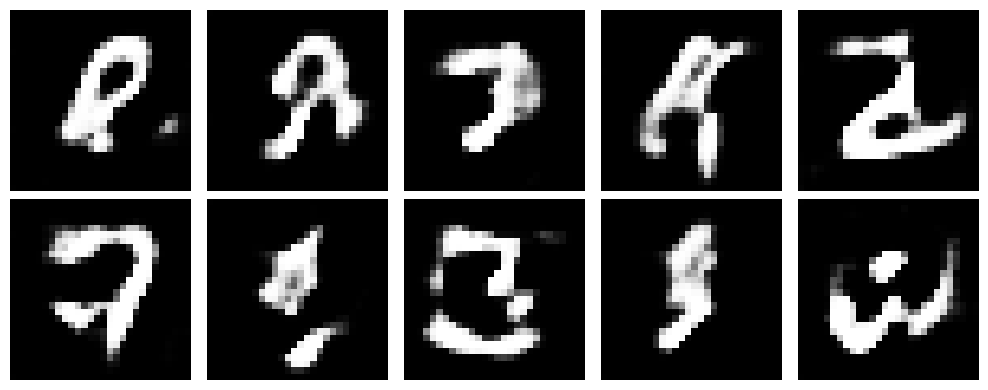

In [25]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Dense, Reshape, Conv2D, Conv2DTranspose,
    LeakyReLU, BatchNormalization, Flatten
)
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Use a smaller dataset for faster training
X_train = X_train[:10000]

# Normalize images to -1 to 1
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

# Add channel dimension
X_train = np.expand_dims(X_train, axis=-1)

# -----------------------------
# Generator
# -----------------------------

generator = Sequential([
    Dense(7 * 7 * 128, input_shape=(100,)),
    BatchNormalization(),
    LeakyReLU(0.2),

    Reshape((7, 7, 128)),

    Conv2DTranspose(
        64, (4, 4),
        strides=(2, 2),
        padding="same"
    ),
    BatchNormalization(),
    LeakyReLU(0.2),

    Conv2DTranspose(
        32, (4, 4),
        strides=(2, 2),
        padding="same"
    ),
    BatchNormalization(),
    LeakyReLU(0.2),

    Conv2D(
        1, (3, 3),
        padding="same",
        activation="tanh"
    )
])

# -----------------------------
# Discriminator
# -----------------------------

discriminator = Sequential([
    Conv2D(
        64, (3, 3),
        strides=(2, 2),
        padding="same",
        input_shape=(28, 28, 1)
    ),
    LeakyReLU(0.2),

    Conv2D(
        128, (3, 3),
        strides=(2, 2),
        padding="same"
    ),
    LeakyReLU(0.2),

    Flatten(),

    Dense(1, activation="sigmoid")
])

# Compile discriminator
discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Freeze discriminator while training generator
discriminator.trainable = False

# -----------------------------
# GAN
# -----------------------------

gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss="binary_crossentropy"
)

# -----------------------------
# Training
# -----------------------------

epochs = 30
batch_size = 64

for epoch in range(epochs):

    for step in range(len(X_train) // batch_size):

        # Real images
        idx = np.random.randint(
            0,
            X_train.shape[0],
            batch_size
        )

        real_images = X_train[idx]

        # Generate fake images
        noise = np.random.normal(
            0, 1,
            (batch_size, 100)
        )

        fake_images = generator.predict(
            noise,
            verbose=0
        )

        # Labels
        real_labels = np.ones((batch_size, 1))
        fake_labels = np.zeros((batch_size, 1))

        # Train discriminator
        discriminator.trainable = True

        d_loss_real = discriminator.train_on_batch(
            real_images,
            real_labels
        )

        d_loss_fake = discriminator.train_on_batch(
            fake_images,
            fake_labels
        )

        # Train generator
        discriminator.trainable = False

        noise = np.random.normal(
            0, 1,
            (batch_size, 100)
        )

        g_loss = gan.train_on_batch(
            noise,
            real_labels
        )

    print(
        "Epoch:", epoch + 1,
        "D Loss:",
        round((d_loss_real[0] + d_loss_fake[0]) / 2, 4),
        "G Loss:",
        round(float(g_loss), 4)
    )

# -----------------------------
# Generate images
# -----------------------------

noise = np.random.normal(0, 1, (10, 100))

generated_images = generator.predict(
    noise,
    verbose=0
)

# Display images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()